<a href="https://colab.research.google.com/github/2403a54127-lab/Natural-language-processing/blob/main/NLP_lab_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install gensim
import gensim
import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

Load Dataset

In [23]:
df = pd.read_csv("/content/spam_sample.csv", encoding='latin-1')

print(df.head())
print(df['label'].value_counts())

  label                           text
0   ham                Hey how are you
1   ham            Let's meet tomorrow
2  spam          Win a free ticket now
3   ham           Are you coming today
4  spam  Congratulations you won prize
label
ham     6
spam    4
Name: count, dtype: int64


Text Preprocessing

In [24]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['text'] = df['text'].apply(clean_text)

# Tokenization
df['tokens'] = df['text'].apply(lambda x: x.split())

Vocabulary

In [25]:
all_words = [word for tokens in df['tokens'] for word in tokens]
vocab = Counter(all_words)

word2idx = {word: i+2 for i, (word, _) in enumerate(vocab.items())}
word2idx[""] = 0
word2idx[""] = 1

vocab_size = len(word2idx)


Mini Pretrained Embeddings

In [26]:
embedding_dim = 50

# Fake small embedding dictionary
embeddings_index = {
    "free": np.random.rand(50),
    "win": np.random.rand(50),
    "call": np.random.rand(50),
    "offer": np.random.rand(50),
    "you": np.random.rand(50),
    "now": np.random.rand(50),
    "hello": np.random.rand(50)
}

# Create embedding matrix
# The vocab_size from the previous cell is len(word2idx), which is 34.
# However, the maximum index assigned in word2idx is 34 (for 'reward').
# To accommodate index 34, the matrix needs size 34 + 1 = 35.
embedding_matrix_size = max(word2idx.values()) + 1
embedding_matrix = np.zeros((embedding_matrix_size, embedding_dim))

for word, idx in word2idx.items():
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
    else:
        embedding_matrix[idx] = np.random.rand(embedding_dim)

Encoding + Padding and Train–Test Split

In [27]:
max_len = 20

def encode(tokens):
    encoded = [word2idx.get(word, 1) for word in tokens]
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    return encoded

X = np.array(df['tokens'].apply(encode).tolist())
y = np.array([1 if label == 'spam' else 0 for label in df['label']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

CNN Model

In [28]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.conv = nn.Conv1d(embedding_dim, 100, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.fc = nn.Linear(100, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = torch.max(x, dim=2)[0]
        x = self.fc(x)
        return self.sigmoid(x)


Training

Evaluation

In [30]:
model.eval()

X_test_tensor = torch.LongTensor(X_test)

with torch.no_grad():
    predictions = model(X_test_tensor).squeeze()
    preds = (predictions > 0.5).int().numpy()

print("\nClassification Report:")
print(classification_report(y_test, preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:
[[2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [31]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size_for_embedding, embedding_dim, embedding_matrix):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size_for_embedding, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.conv = nn.Conv1d(embedding_dim, 100, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.fc = nn.Linear(100, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = torch.max(x, dim=2)[0]
        x = self.fc(x)
        return self.sigmoid(x)

model = TextCNN(embedding_matrix_size, embedding_dim, embedding_matrix)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)

for epoch in range(5):
    model.train()

    outputs = model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.7053143382072449
Epoch 2, Loss: 0.6796692609786987
Epoch 3, Loss: 0.6575797200202942
Epoch 4, Loss: 0.6373599171638489
Epoch 5, Loss: 0.6186221837997437


In [32]:
model.eval()

X_test_tensor = torch.LongTensor(X_test)

with torch.no_grad():
    predictions = model(X_test_tensor).squeeze()
    preds = (predictions > 0.5).int().numpy()

print("\nClassification Report:")
print(classification_report(y_test, preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Confusion Matrix:
[[0 2]
 [0 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

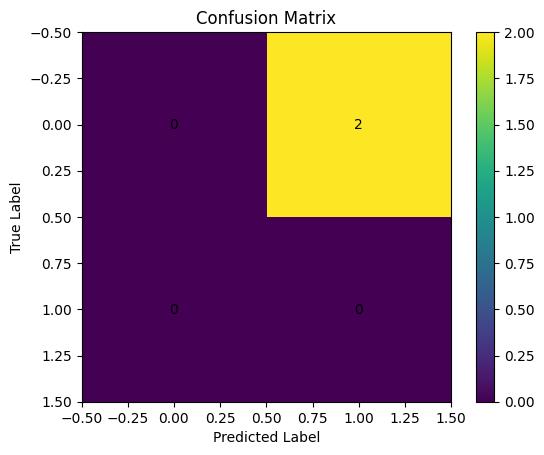

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [34]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size_for_embedding, embedding_dim, embedding_matrix):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size_for_embedding, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.conv = nn.Conv1d(embedding_dim, 100, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.fc = nn.Linear(100, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = torch.max(x, dim=2)[0]
        x = self.fc(x)
        return self.sigmoid(x)

model = TextCNN(embedding_matrix_size, embedding_dim, embedding_matrix)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)

for epoch in range(5):
    model.train()

    outputs = model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.6922629475593567
Epoch 2, Loss: 0.661198616027832
Epoch 3, Loss: 0.6359092593193054
Epoch 4, Loss: 0.6142323017120361
Epoch 5, Loss: 0.5939979553222656


In [35]:
model.eval()

X_test_tensor = torch.LongTensor(X_test)

with torch.no_grad():
    predictions = model(X_test_tensor).squeeze()
    preds = (predictions > 0.5).int().numpy()

print("\nClassification Report:")
print(classification_report(y_test, preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Confusion Matrix:
[[0 2]
 [0 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Confusion Matrix

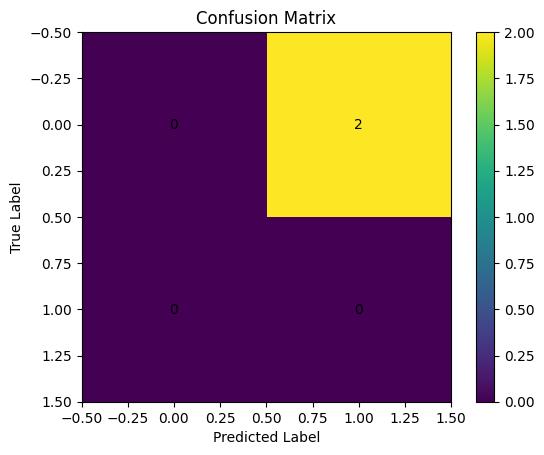

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()



Compilation (Optimizer + Loss + Metrics)

In [37]:
# Loss Function
criterion = nn.BCELoss()   # Binary Cross Entropy for binary classification

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)   # Adam optimizer

# Metrics Function
def calculate_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    y_pred = (y_pred > 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, f1

Metrics (during evaluation)

In [38]:
# Convert predictions
preds = predictions.detach().numpy()

# Calculate metrics
accuracy, precision, recall, f1 = calculate_metrics(y_test, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
